# D4 — Developer Influence (PageRank / HITS)

Reads PageRank + HITS scores from GCS and produces:
- Top developer rankings by PageRank
- Hub vs Authority scatter
- Degree distribution
- Commits vs PageRank correlation

> **Privacy note**: developer identities are SHA-256 hashed; raw emails are never stored or displayed.

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = '../service-account-key.json'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

BUCKET = 'github-tech-trends-data'
sns.set_theme(style='whitegrid')
print('Environment ready.')

Environment ready.


## 1. Load data

In [2]:
df = pd.read_parquet(f'gs://{BUCKET}/processed/d4_pagerank/')
print(f'Developers: {len(df):,}')
print('Columns:', df.columns.tolist())
df.describe()

Developers: 25,000
Columns: ['dev_id', 'pagerank', 'hub_score', 'auth_score', 'degree', 'total_commits']


,pagerank,hub_score,auth_score,degree,total_commits
count,25000.000000,25000.000000,25000.000000,25000.00000,2.500000e+04
mean,0.000040,0.000062,0.000062,7.67584,8.789000e+03
std,0.000050,0.000242,0.000242,15.34350,6.431385e+04
min,0.000009,0.000000,0.000000,0.00000,2.140000e+02
25%,0.000009,0.000000,0.000000,0.00000,1.810750e+03
50%,0.000018,0.000000,0.000000,2.00000,3.987500e+03
75%,0.000057,0.000039,0.000039,8.00000,7.801250e+03
max,0.000791,0.009278,0.009278,211.00000,4.895176e+06


## 2. Top 20 developers by PageRank

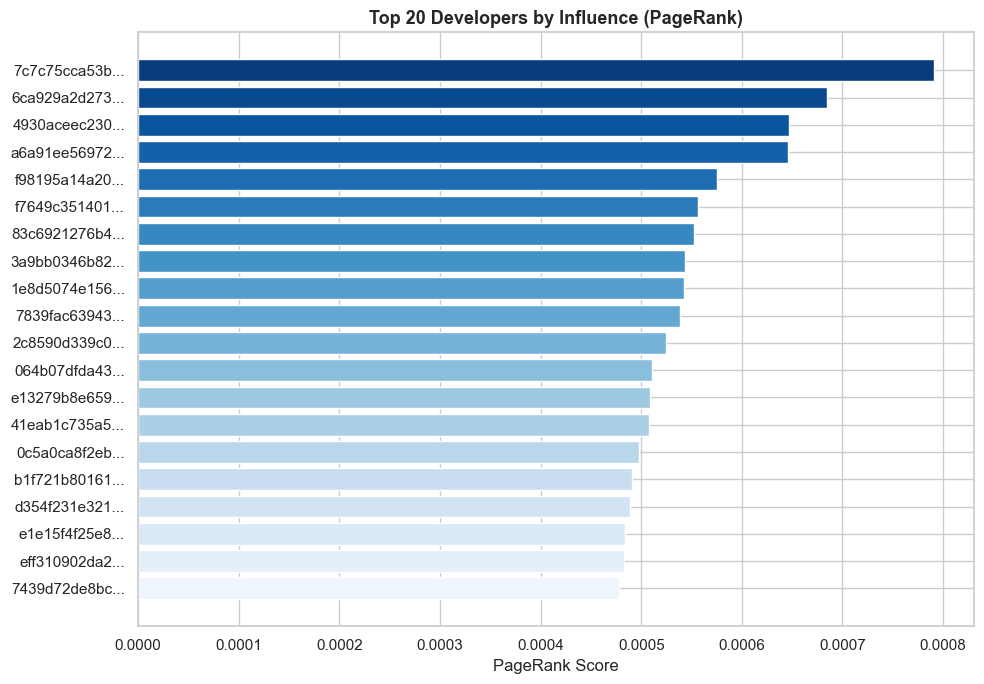


Top 20 table:


,dev_short,pagerank,hub_score,auth_score,degree,total_commits
0,7c7c75cca53b...,0.000791,0.000748,0.000748,95,4331
1,6ca929a2d273...,0.000685,0.009278,0.009278,180,39491
2,4930aceec230...,0.000647,0.003234,0.003234,97,37076
3,a6a91ee56972...,0.000646,0.001228,0.001228,121,789541
4,f98195a14a20...,0.000575,0.000111,0.000111,68,4328
5,f7649c351401...,0.000557,0.001695,0.001695,154,25288
6,83c6921276b4...,0.000552,0.000231,0.000231,55,34096
7,3a9bb0346b82...,0.000544,0.000036,0.000036,66,2808
8,1e8d5074e156...,0.000543,0.002734,0.002734,127,32686
9,7839fac63943...,0.000538,0.002672,0.002672,121,16521


In [3]:
top20_pr = df.nlargest(20, 'pagerank').reset_index(drop=True)
# Show truncated dev_id for readability
top20_pr['dev_short'] = top20_pr['dev_id'].str[:12] + '...'

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top20_pr['dev_short'], top20_pr['pagerank'],
               color=sns.color_palette('Blues_r', 20))
ax.set_xlabel('PageRank Score')
ax.set_title('Top 20 Developers by Influence (PageRank)', fontsize=13, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../outputs/d4_top20_pagerank.png', dpi=150)
plt.show()

print('\nTop 20 table:')
top20_pr[['dev_short', 'pagerank', 'hub_score', 'auth_score', 'degree', 'total_commits']]

## 3. Hub vs Authority scores scatter

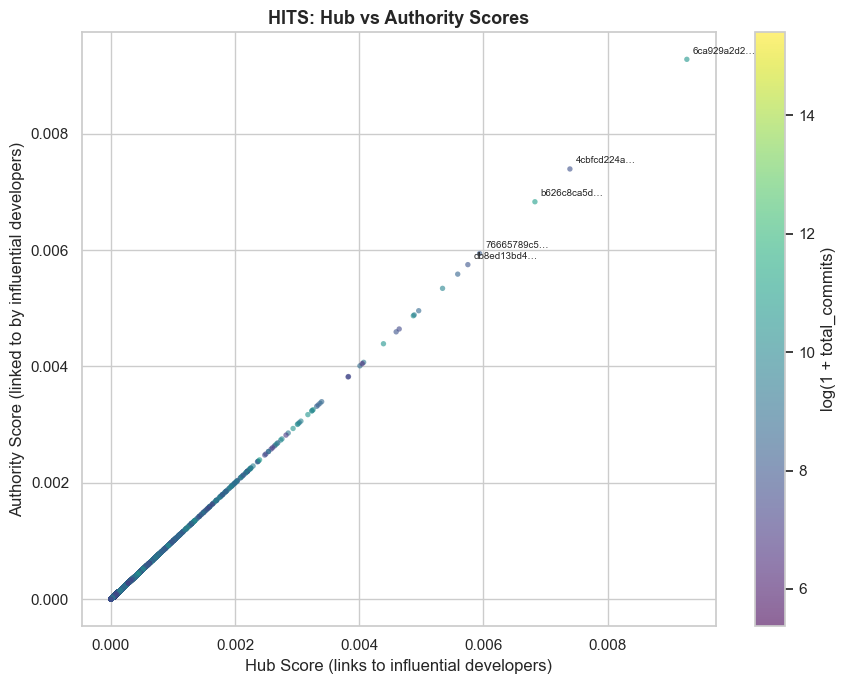

In [4]:
fig, ax = plt.subplots(figsize=(9, 7))

scatter = ax.scatter(
    df['hub_score'], df['auth_score'],
    c=np.log1p(df['total_commits']),
    cmap='viridis', alpha=0.6, s=15, edgecolors='none',
)
plt.colorbar(scatter, ax=ax, label='log(1 + total_commits)')

# Annotate extreme points
top_hub  = df.nlargest(5, 'hub_score')
top_auth = df.nlargest(5, 'auth_score')
for _, row in pd.concat([top_hub, top_auth]).drop_duplicates().iterrows():
    ax.annotate(row['dev_id'][:10] + '…',
                (row['hub_score'], row['auth_score']),
                fontsize=7, xytext=(4, 4), textcoords='offset points')

ax.set_xlabel('Hub Score (links to influential developers)')
ax.set_ylabel('Authority Score (linked to by influential developers)')
ax.set_title('HITS: Hub vs Authority Scores', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/d4_hub_authority.png', dpi=150)
plt.show()

## 4. Degree distribution

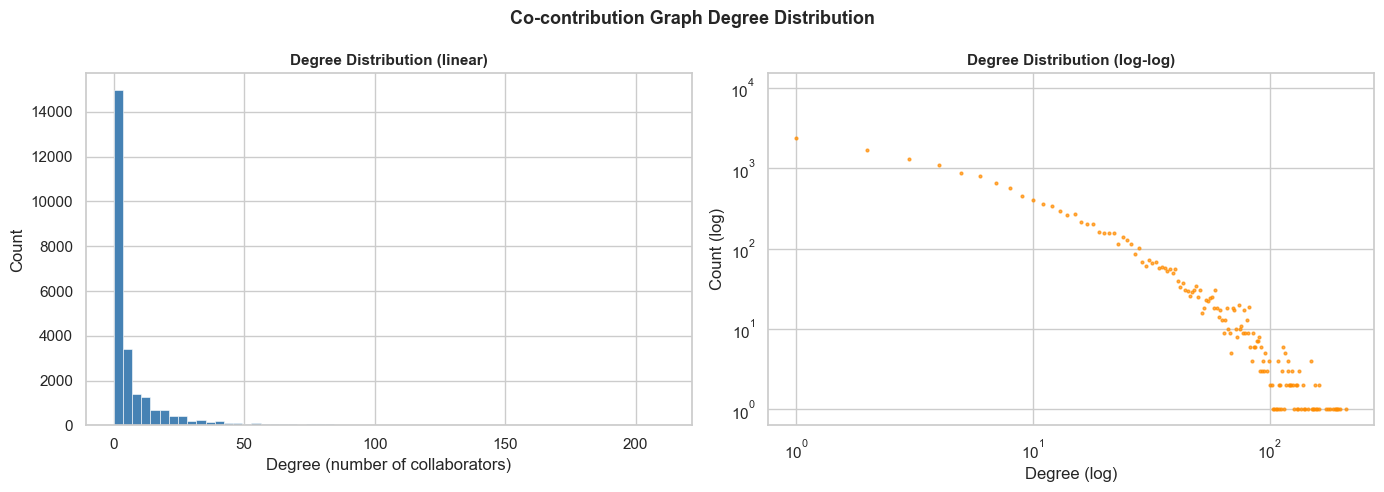

Mean degree  : 7.7
Max degree   : 211
Isolated (degree=0): 9625


In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale
ax1.hist(df['degree'], bins=60, color='steelblue', edgecolor='white', linewidth=0.4)
ax1.set_xlabel('Degree (number of collaborators)')
ax1.set_ylabel('Count')
ax1.set_title('Degree Distribution (linear)', fontsize=11, fontweight='bold')

# Log-log scale — check for power-law
degree_counts = df['degree'].value_counts().sort_index()
ax2.loglog(degree_counts.index, degree_counts.values, '.', markersize=4,
           color='darkorange', alpha=0.7)
ax2.set_xlabel('Degree (log)')
ax2.set_ylabel('Count (log)')
ax2.set_title('Degree Distribution (log-log)', fontsize=11, fontweight='bold')

plt.suptitle('Co-contribution Graph Degree Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/d4_degree_distribution.png', dpi=150)
plt.show()

print(f'Mean degree  : {df["degree"].mean():.1f}')
print(f'Max degree   : {df["degree"].max()}')
print(f'Isolated (degree=0): {(df["degree"] == 0).sum()}')

## 5. PageRank vs total commits

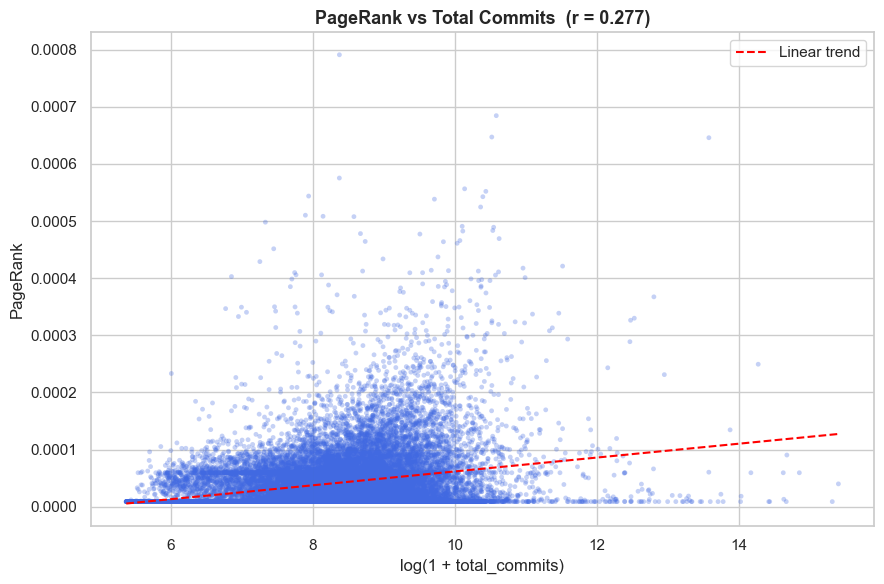

In [6]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(
    np.log1p(df['total_commits']), df['pagerank'],
    alpha=0.3, s=12, color='royalblue', edgecolors='none',
)

# Trend line
x = np.log1p(df['total_commits'])
z = np.polyfit(x, df['pagerank'], 1)
p = np.poly1d(z)
xline = np.linspace(x.min(), x.max(), 200)
ax.plot(xline, p(xline), color='red', linewidth=1.5, linestyle='--', label='Linear trend')

corr = np.corrcoef(x, df['pagerank'])[0, 1]
ax.set_title(f'PageRank vs Total Commits  (r = {corr:.3f})',
             fontsize=13, fontweight='bold')
ax.set_xlabel('log(1 + total_commits)')
ax.set_ylabel('PageRank')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/d4_pagerank_vs_commits.png', dpi=150)
plt.show()

## 6. PageRank distribution (log scale)

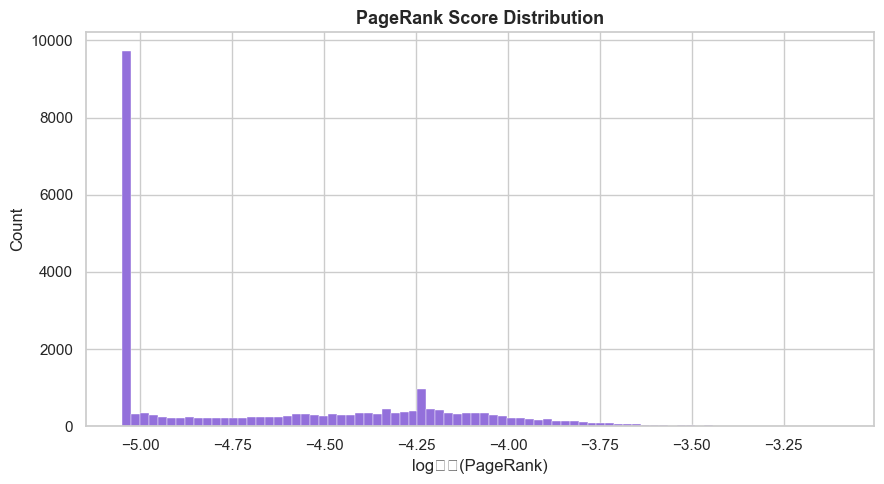

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(np.log10(df['pagerank'] + 1e-10), bins=80,
        color='mediumpurple', edgecolor='white', linewidth=0.3)
ax.set_xlabel('log₁₀(PageRank)')
ax.set_ylabel('Count')
ax.set_title('PageRank Score Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/d4_pagerank_dist.png', dpi=150)
plt.show()